# Experiment 4: Prompt Engineering + Fine-Tuning (PE + FT)

**Method:** Fine-Tuned model with optimized prompt (NO few-shot examples)


In [1]:
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: Tesla T4


In [2]:
!pip install -q bitsandbytes accelerate peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 34.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.3 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 101.9 MB/s eta 0:00:0000:0100:01
ERROR: pip's de

In [3]:
import json
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from huggingface_hub import login

warnings.filterwarnings('ignore')
print("Imports done!")

2025-12-15 16:21:57.329155: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765815717.653865      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765815717.749414      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Imports done!


In [4]:
from kaggle_secrets import UserSecretsClient
HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
login(token=HF_TOKEN)
print("Logged in!")

Logged in!


In [5]:
json_files = glob.glob('/kaggle/input/**/*.json', recursive=True)
print(f"Found: {json_files}")

dataset_raw = None
for f in json_files:
    with open(f, 'r') as file:
        data = json.load(file)
    if isinstance(data, list) and len(data) > 100:
        dataset_raw = data
        print(f"Loaded: {len(dataset_raw)} samples")
        break

Found: ['/kaggle/input/solana-dataset/solana_182_final.json', '/kaggle/input/solana-fine-tuned-model/solana-fine-tuned-model/adapter_config.json', '/kaggle/input/solana-fine-tuned-model/solana-fine-tuned-model/tokenizer.json', '/kaggle/input/solana-fine-tuned-model/solana-fine-tuned-model/tokenizer_config.json', '/kaggle/input/solana-fine-tuned-model/solana-fine-tuned-model/special_tokens_map.json']
Loaded: 182 samples


In [6]:
by_type = defaultdict(list)
for sample in dataset_raw:
    by_type[sample['vulnerability_type']].append(sample)

train_data, val_data, test_data = [], [], []

for vtype, samples in by_type.items():
    labels = [s['label'] for s in samples]
    train_s, temp_s = train_test_split(samples, test_size=0.2, stratify=labels, random_state=42)
    temp_labels = [s['label'] for s in temp_s]
    val_s, test_s = train_test_split(temp_s, test_size=0.5, stratify=temp_labels, random_state=42)
    train_data.extend(train_s)
    val_data.extend(val_s)
    test_data.extend(test_s)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

Train: 140 | Val: 21 | Test: 21


In [7]:
MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"
ADAPTER_PATH = "/kaggle/input/solana-fine-tuned-model/solana-fine-tuned-model"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("Loading base model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    token=HF_TOKEN
)

print("Loading fine-tuned adapter...")
model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model.eval()
print("Model ready!")

Loading base model...


tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Loading fine-tuned adapter...
Model ready!


In [8]:
def extract_code(sample):
    text = sample.get('text', '')
    if '<|start_header_id|>user<|end_header_id|>' in text:
        start = text.find('<|start_header_id|>user<|end_header_id|>') + len('<|start_header_id|>user<|end_header_id|>')
        end = text.find('<|eot_id|><|start_header_id|>assistant')
        if end > start:
            code = text[start:end].strip()
            return code.replace('```rust', '').replace('```', '').strip()
    return text[:1500]

## PE + FT Prediction

Using Fine-Tuned model with Role-based Prompt Engineering (NO few-shot examples)

In [9]:
def predict_pe_ft(sample):
    code = extract_code(sample)
    
    prompt = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a Solana smart contract security auditor. Analyze the provided Rust code for vulnerabilities.
Classify the code as either VULNERABLE or SAFE.<|eot_id|><|start_header_id|>user<|end_header_id|>

```rust
{code[:1000]}
```<|eot_id|><|start_header_id|>assistant<|end_header_id|>

"""
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1500)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    response = response.strip().upper()
    
    if 'VULNERABLE' in response:
        return 'VULNERABLE'
    elif 'SAFE' in response:
        return 'SAFE'
    return 'VULNERABLE'

print("Testing...")
for i in range(3):
    pred = predict_pe_ft(test_data[i])
    print(f"  Sample {i+1}: {pred} (Actual: {test_data[i]['label']})")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Testing...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Sample 1: VULNERABLE (Actual: SAFE)


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Sample 2: SAFE (Actual: SAFE)
  Sample 3: SAFE (Actual: VULNERABLE)


In [10]:
print(f"Evaluating {len(test_data)} samples...")

results = []
for sample in tqdm(test_data, desc="Testing"):
    pred = predict_pe_ft(sample)
    results.append({
        'vulnerability_type': sample['vulnerability_type'],
        'ground_truth': sample['label'],
        'prediction': pred,
        'correct': sample['label'] == pred
    })

print(f"\nCorrect: {sum(r['correct'] for r in results)}/{len(results)}")

Evaluating 21 samples...


Testing: 100%|██████████| 21/21 [00:11<00:00,  1.81it/s]


Correct: 15/21


In [11]:
print("\nDetailed Results:")
print("-" * 70)
for i, r in enumerate(results, 1):
    status = "✓" if r['correct'] else "✗"
    print(f"{i:2}. {r['vulnerability_type']:<20} True: {r['ground_truth']:<12} Pred: {r['prediction']:<12} {status}")
print("-" * 70)


Detailed Results:
----------------------------------------------------------------------
 1. Integer Flow         True: SAFE         Pred: VULNERABLE   ✗
 2. Integer Flow         True: SAFE         Pred: SAFE         ✓
 3. Integer Flow         True: VULNERABLE   Pred: SAFE         ✗
 4. Type Confusion       True: SAFE         Pred: SAFE         ✓
 5. Type Confusion       True: SAFE         Pred: SAFE         ✓
 6. Type Confusion       True: VULNERABLE   Pred: VULNERABLE   ✓
 7. DoS                  True: SAFE         Pred: SAFE         ✓
 8. DoS                  True: SAFE         Pred: SAFE         ✓
 9. DoS                  True: VULNERABLE   Pred: VULNERABLE   ✓
10. Bump Seed            True: SAFE         Pred: SAFE         ✓
11. Bump Seed            True: SAFE         Pred: SAFE         ✓
12. Bump Seed            True: VULNERABLE   Pred: SAFE         ✗
13. Unchecked Calls      True: SAFE         Pred: SAFE         ✓
14. Unchecked Calls      True: SAFE         Pred: SAFE         ✓


In [12]:
all_gt = [r['ground_truth'] for r in results]
all_pred = [r['prediction'] for r in results]

accuracy = accuracy_score(all_gt, all_pred)
precision = precision_score(all_gt, all_pred, pos_label='VULNERABLE', zero_division=0)
recall = recall_score(all_gt, all_pred, pos_label='VULNERABLE', zero_division=0)
f1 = f1_score(all_gt, all_pred, pos_label='VULNERABLE', zero_division=0)

print("=" * 50)
print("EXPERIMENT 4: PE + FT RESULTS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1-Score:  {f1:.2%}")
print("=" * 50)

EXPERIMENT 4: PE + FT RESULTS
Accuracy:  71.43%
Precision: 60.00%
Recall:    42.86%
F1-Score:  50.00%


In [13]:
print("\nPer-Vulnerability Type:")
print("-" * 50)

metrics_by_type = {}
for vtype in sorted(set(r['vulnerability_type'] for r in results)):
    type_results = [r for r in results if r['vulnerability_type'] == vtype]
    gt = [r['ground_truth'] for r in type_results]
    pred = [r['prediction'] for r in type_results]
    acc = accuracy_score(gt, pred)
    metrics_by_type[vtype] = {'accuracy': acc, 'count': len(type_results)}
    print(f"{vtype:<20}: {acc:.2%} ({len(type_results)} samples)")

print("-" * 50)
print(f"{'AVERAGE':<20}: {np.mean([m['accuracy'] for m in metrics_by_type.values()]):.2%}")


Per-Vulnerability Type:
--------------------------------------------------
Bump Seed           : 66.67% (3 samples)
CPI                 : 33.33% (3 samples)
DoS                 : 100.00% (3 samples)
Integer Flow        : 33.33% (3 samples)
Missing Key Check   : 100.00% (3 samples)
Type Confusion      : 100.00% (3 samples)
Unchecked Calls     : 66.67% (3 samples)
--------------------------------------------------
AVERAGE             : 71.43%


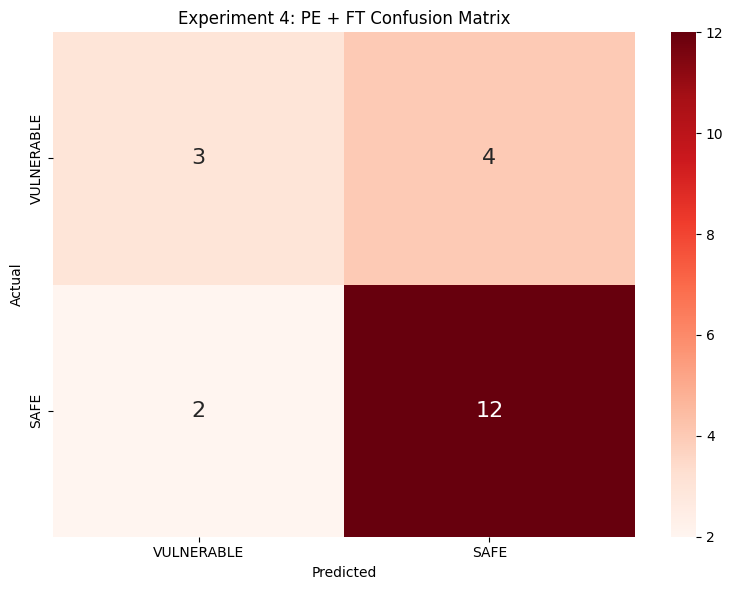


TP: 3 | FN: 4
FP: 2 | TN: 12


In [14]:
cm = confusion_matrix(all_gt, all_pred, labels=['VULNERABLE', 'SAFE'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['VULNERABLE', 'SAFE'],
            yticklabels=['VULNERABLE', 'SAFE'],
            annot_kws={'size': 16})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Experiment 4: PE + FT Confusion Matrix')
plt.tight_layout()
plt.savefig('/kaggle/working/cm_pe_ft.png', dpi=150)
plt.show()

print(f"\nTP: {cm[0,0]} | FN: {cm[0,1]}")
print(f"FP: {cm[1,0]} | TN: {cm[1,1]}")

In [15]:
pd.DataFrame(results).to_csv('/kaggle/working/results_pe_ft.csv', index=False)

summary = {
    'experiment': 'Prompt Engineering + Fine-Tuning (PE + FT)',
    'model': MODEL_ID,
    'method': 'Fine-Tuned model with Role-based Prompt (NO few-shot)',
    'dataset_size': len(dataset_raw),
    'test_size': len(test_data),
    'results': {
        'accuracy': round(accuracy, 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1_score': round(f1, 4)
    },
    'confusion_matrix': {'TP': int(cm[0,0]), 'FN': int(cm[0,1]), 'FP': int(cm[1,0]), 'TN': int(cm[1,1])},
    'per_vulnerability': metrics_by_type
}

with open('/kaggle/working/summary_pe_ft.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Saved: results_pe_ft.csv, summary_pe_ft.json, cm_pe_ft.png")

Saved: results_pe_ft.csv, summary_pe_ft.json, cm_pe_ft.png


In [16]:
print("\n" + "=" * 50)
print("EXPERIMENT 4 COMPLETE")
print("=" * 50)
print(f"Method: PE + FT (like reference paper)")
print(f"Model: Fine-Tuned {MODEL_ID}")
print(f"Prompt: Role-based (NO few-shot examples)")
print(f"\nResults:")
print(f"  Accuracy:  {accuracy:.2%}")
print(f"  Precision: {precision:.2%}")
print(f"  Recall:    {recall:.2%}")
print(f"  F1-Score:  {f1:.2%}")
print("=" * 50)


EXPERIMENT 4 COMPLETE
Method: PE + FT (like reference paper)
Model: Fine-Tuned meta-llama/Llama-3.1-8B-Instruct
Prompt: Role-based (NO few-shot examples)

Results:
  Accuracy:  71.43%
  Precision: 60.00%
  Recall:    42.86%
  F1-Score:  50.00%
